##Data Understanding & Preprocessing (PySpark/Dask)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
!pip install dask pyspark

In [2]:
import pandas as pd
df = pd.read_csv("Your_file_path_here")

##What is Dask?
Dask is a flexible library for parallel computing in Python. It allows you to scale your Python code from single-core machines to distributed clusters. In essence, Dask provides a way to manage larger-than-memory datasets and speed up computations by breaking them down into smaller tasks that can be executed in parallel.

In [3]:

import dask.dataframe as dd
ddf = dd.from_pandas(df, npartitions=4)

In [4]:
df.describe()


,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude
count,7.842937e+06,7.842937e+06,7.842890e+06,7.228088e+06,7.229461e+06,7.754915e+06,7.754915e+06,7.842937e+06,7.754915e+06,7.754915e+06
mean,7.071242e+06,1.185692e+03,1.129491e+01,2.275678e+01,3.747550e+01,1.164606e+06,1.885793e+06,2.010041e+03,4.184221e+01,-8.767148e+01
std,3.528350e+06,7.032076e+02,6.953709e+00,1.385103e+01,2.154170e+01,1.684307e+04,3.227163e+04,6.336775e+00,8.878555e-02,6.107159e-02
min,6.340000e+02,1.110000e+02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.001000e+03,3.661945e+01,-9.168657e+01
25%,3.814349e+06,6.210000e+02,6.000000e+00,1.000000e+01,2.300000e+01,1.152984e+06,1.859078e+06,2.005000e+03,4.176873e+01,-8.771366e+01
50%,7.072857e+06,1.034000e+03,1.000000e+01,2.300000e+01,3.200000e+01,1.166120e+06,1.890736e+06,2.009000e+03,4.185593e+01,-8.766582e+01
75%,1.020682e+07,1.731000e+03,1.700000e+01,3.400000e+01,5.700000e+01,1.176383e+06,1.909281e+06,2.015000e+03,4.190680e+01,-8.762818e+01
max,1.314245e+07,2.535000e+03,3.100000e+01,5.000000e+01,7.700000e+01,1.205119e+06,1.951622e+06,2.023000e+03,4.202291e+01,-8.752453e+01


In [ ]:
df['Primary Type'].value_counts()


,count
Primary Type,
THEFT,1654618
BATTERY,1433129
CRIMINAL DAMAGE,894068
NARCOTICS,748690
ASSAULT,512441
OTHER OFFENSE,486983
BURGLARY,426001
MOTOR VEHICLE THEFT,381815
DECEPTIVE PRACTICE,348897


<Axes: xlabel='Domestic', ylabel='Count'>

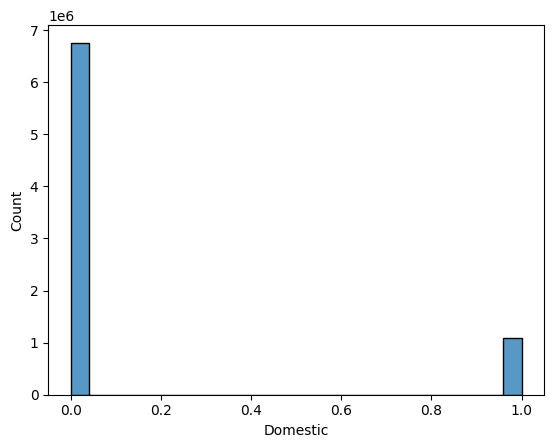

In [ ]:
import seaborn as sns
sns.histplot(df['Domestic'])

#Working with Spark DataFrames

##What is PySpark?
PySpark is the Python API for Apache Spark, a powerful open-source unified analytics engine for large-scale data processing. Spark is designed for fast and general-purpose cluster computing

##Pyspark vs Dask

PySpark is the Python API for Apache Spark, a big data processing engine designed for **large-scale distributed computing** with an optimized execution engine for structured data. Dask is a flexible Python library for **parallel computing** that integrates with existing Python libraries and is suitable for both single-machine and distributed tasks. Spark is often better for **large-scale ETL **and **SQL-like** operations on clusters, while Dask offers more flexibility for **arbitrary Python code** and **easier integration** with the Python data science stack.

In [5]:
from pyspark.sql import SparkSession

In [6]:
spark = SparkSession.builder \
    .appName("Chicago Crime Analysis") \
    .getOrCreate()

In [7]:
spark.sparkContext.getConf().getAll()


[('spark.app.name', 'Chicago Crime Analysis'),
 ('spark.driver.extraJavaOptions',
  '-Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/jdk.internal.ref=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED --add-opens=java.base/sun.util.calendar=ALL-UNNAMED --add-opens=java.security.jgss/sun.security.krb5=ALL-UNNAMED -Djdk.reflect.useDirectMethodHandle=false'),
 ('spark.app.submitTime', '1760772552899'),
 ('spark.dri

In [16]:
df = spark.read.csv('/content/drive/MyDrive/archive (1)/Crimes_-_2001_to_Present.csv', header=True, inferSchema=True)
df.printSchema()


root
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: integer (nullable = true)
 |-- Y Coordinate: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Location: string (nullable = true)



In [9]:
df.show(5)   # head



+--------+-----------+--------------------+--------------------+----+------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+--------+---------+--------+
|      ID|Case Number|                Date|               Block|IUCR|      Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|          Updated On|Latitude|Longitude|Location|
+--------+-----------+--------------------+--------------------+----+------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+--------+---------+--------+
|11646166|   JC213529|09/01/2018 12:01:...|082XX S INGLESIDE...|0810|             THEFT|           OVER $500|           RESIDENCE| false|    true| 631|       6|   8|            44|      06| 

In [ ]:
df.tail(5)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
7842932,13128007,JG325985,06/21/2023 08:00:00 PM,031XX N CALIFORNIA AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,35.0,21.0,14,1157169.0,1920611.0,2023,07/15/2023 04:45:57 PM,41.937926,-87.697782,"(41.937925817, -87.697782474)"
7842933,13129172,JG327619,06/20/2023 04:00:00 AM,028XX N MAPLEWOOD AVE,0460,BATTERY,SIMPLE,RESIDENCE,False,True,...,35.0,21.0,08B,1158868.0,1918755.0,2023,07/15/2023 04:45:57 PM,41.932798,-87.691589,"(41.932798095, -87.691589364)"
7842934,13128066,JG325838,06/06/2023 03:42:00 PM,018XX N LOCKWOOD AVE,1752,OFFENSE INVOLVING CHILDREN,AGGRAVATED CRIMINAL SEXUAL ABUSE BY FAMILY MEMBER,APARTMENT,False,False,...,37.0,25.0,17,1140792.0,1911954.0,2023,07/15/2023 04:45:57 PM,41.914487,-87.758185,"(41.914487492, -87.758185241)"
7842935,13128324,JG326502,05/13/2023 12:00:00 PM,020XX W CERMAK RD,1120,DECEPTIVE PRACTICE,FORGERY,CURRENCY EXCHANGE,False,False,...,25.0,31.0,10,1163211.0,1889404.0,2023,07/15/2023 04:45:57 PM,41.852166,-87.676455,"(41.85216632, -87.676455032)"
7842936,13128375,JG326564,06/24/2023 01:29:00 PM,069XX N HAMILTON AVE,1330,CRIMINAL TRESPASS,TO LAND,RESIDENCE,False,False,...,40.0,2.0,26,1160740.0,1946176.0,2023,07/15/2023 04:45:57 PM,42.008004,-87.683946,"(42.008003927, -87.683946124)"


In [17]:
print("Total rows:", df.count())
print("Total columns:", len(df.columns))


Total rows: 7842937
Total columns: 22


In [18]:
# from pyspark.sql.functions import col

# # Order by date in descending order and take the first 80,000 rows
# df = df.orderBy(col("Date").desc()).limit(80000)

# print("New total rows:", df.count())

New total rows: 80000


In [20]:
# Save the DataFrame to a CSV file in Google Drive
df.write.csv('/content/drive/MyDrive/archive (1)/Crimes_2001_to_Present_subset.csv', header=True, mode='overwrite')

In [19]:
print("Total rows:", df.count())
print("Total columns:", len(df.columns))

Total rows: 80000
Total columns: 22


In [21]:
df= df.drop("X Coordinate", "Y Coordinate","Latitude","Longitude")
df.printSchema()

root
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Location: string (nullable = true)



In [22]:
from pyspark.sql.functions import col, sum

# Check for missing values in each column
missing_values = df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])
missing_values.show()

+---+-----------+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+----+----------+--------+
| ID|Case Number|Date|Block|IUCR|Primary Type|Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|Year|Updated On|Location|
+---+-----------+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+----+----------+--------+
|  0|          0|   0|    0|   0|           0|          0|                 101|     0|       0|   0|       0|4085|          4081|       0|   0|         0|    1917|
+---+-----------+----+-----+----+------------+-----------+--------------------+------+--------+----+--------+----+--------------+--------+----+----------+--------+



In [24]:
from pyspark.sql.functions import col, lit
from pyspark.sql.window import Window
from pyspark.sql.functions import count, desc

# Calculate mode for Ward, Community Area, Location Description, and Location
# Note: Calculating mode on large distributed datasets can be computationally intensive.
# This approach calculates the mode for each column by grouping and counting,
# then selecting the most frequent value.
def calculate_mode(df, column):
    mode_df = df.groupBy(column).count().orderBy(desc("count")).limit(1)
    # Handle case where column is all null or empty
    if mode_df.count() > 0:
        return mode_df.collect()[0][0]
    else:
        return None # Or a suitable placeholder

ward_mode = calculate_mode(df.filter(col("Ward").isNotNull()), "Ward")
community_area_mode = calculate_mode(df.filter(col("Community Area").isNotNull()), "Community Area")
location_description_mode = calculate_mode(df.filter(col("Location Description").isNotNull()), "Location Description")
location_mode = calculate_mode(df.filter(col("Location").isNotNull()), "Location")


# Fill missing values
df = df.na.fill({"Ward": ward_mode if ward_mode is not None else 0,
                 "Community Area": community_area_mode if community_area_mode is not None else 0,
                 "Location Description": location_description_mode if location_description_mode is not None else "Unknown",
                 "Location": location_mode if location_mode is not None else "Unknown",
                 "Case Number": "Unknown"})

# Verify missing values are filled
missing_values_after_fill = df.select([sum(col(c).isNull().cast("int")).alias(c) for c in ["Case Number", "Ward", "Community Area", "Location Description", "Location"]])
missing_values_after_fill.show()

+-----------+----+--------------+--------------------+--------+
|Case Number|Ward|Community Area|Location Description|Location|
+-----------+----+--------------+--------------------+--------+
|          0|   0|             0|                   0|       0|
+-----------+----+--------------+--------------------+--------+



In [26]:
from pyspark.sql.functions import to_timestamp, year, month, dayofweek, hour

df = df.withColumn("Date", to_timestamp("Date", "MM/dd/yyyy hh:mm:ss a"))
df = df.withColumn("Year", year("Date")) \
       .withColumn("Month", month("Date")) \
       .withColumn("DayOfWeek", dayofweek("Date")) \
       .withColumn("Hour", hour("Date"))

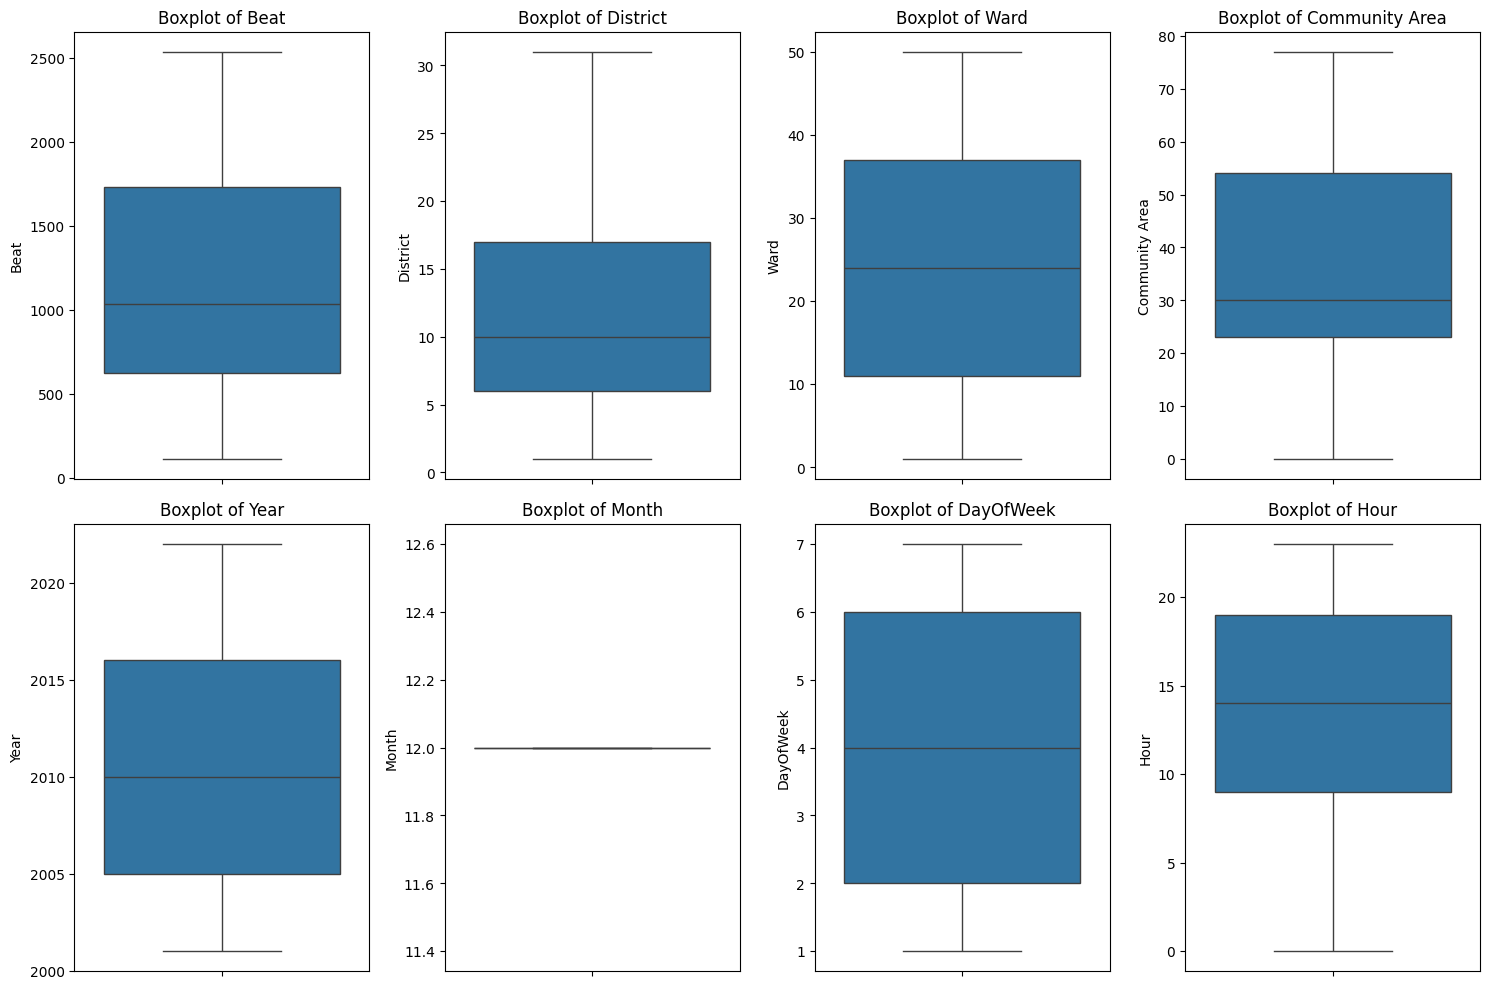

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select numerical columns for plotting
numerical_cols = ["Beat", "District", "Ward", "Community Area", "Year", "Month", "DayOfWeek", "Hour"]

# Convert the selected columns to a pandas DataFrame for plotting
# Note: Collecting data to the driver node for plotting. Be mindful of memory usage for larger datasets.
df_pandas = df.select(numerical_cols).toPandas()

# Generate boxplots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=df_pandas[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [93]:
# Save the preprocessed DataFrame to a CSV file in Google Drive
# Using mode='overwrite' will replace the file if it already exists
df.write.csv('/content/drive/MyDrive/archive (1)/Crimes_2001_to_Present_preprocessed.csv', header=True, mode='overwrite')

In [ ]:
# # Load the preprocessed DataFrame from the CSV file
# df = spark.read.csv('/content/drive/MyDrive/archive (1)/Crimes_2001_to_Present_preprocessed.csv', header=True, inferSchema=True)

# # Show the schema and a few rows to verify
# df.printSchema()
# df.show(5)

##What are RRD?
In the context of Apache Spark (which PySpark is based on), RDD stands for **Resilient Distributed Dataset**.

Resilient: This means RDDs are fault-tolerant. If a partition of an RDD is lost due to a node failure, it can be rebuilt from the original data using the lineage of transformations.
Distributed: RDDs are spread across multiple nodes in a cluster, allowing for parallel processing of large datasets.
Dataset: This represents a collection of data, which can be structured or unstructured.

RDDs are the fundamental data structure in Spark. DataFrames, which you are currently working with, are a higher-level abstraction built on top of RDDs. DataFrames provide more structure and allow Spark to perform optimizations that are not possible with raw RDDs, making them generally more efficient for structured data processing. While you can work directly with RDDs, DataFrames are often preferred for most common data manipulation and analysis tasks in Spark.

In [34]:
rdd_from_list = spark.sparkContext.parallelize([1, 2, 3, 4, 5])
rdd_from_df = df.select("Primary Type").rdd


In [35]:
rdd_mapped = rdd_from_list.map(lambda x: x * 2)
rdd_filtered = rdd_mapped.filter(lambda x: x > 5)
rdd_flat = rdd_from_list.flatMap(lambda x: [x, x**2])


In [36]:
print(rdd_filtered.collect())
print(rdd_from_list.count())
print(rdd_from_list.take(3))
print(rdd_from_list.reduce(lambda x, y: x + y))


[6, 8, 10]
5
[1, 2, 3]
15


In [37]:
kv_rdd = spark.sparkContext.parallelize([("Theft", 1), ("Assault", 1), ("Theft", 1)])
reduced = kv_rdd.reduceByKey(lambda a, b: a + b)
grouped = kv_rdd.groupByKey().mapValues(list)
print(reduced.collect())
print(grouped.collect())


[('Theft', 2), ('Assault', 1)]
[('Theft', [1, 1]), ('Assault', [1])]


1. aggregateByKey() – Example: Average Number of Crimes per Year by Primary Type

In [57]:
from pyspark.sql import functions as F

# Select columns and convert to RDD
rdd = df.select("Primary Type", "Year").rdd.map(lambda row: ((row["Primary Type"], row["Year"]), 1))

# aggregateByKey to get total crimes and count per (type, year)
rdd_agg = rdd.aggregateByKey(
    (0, 0),  # (sum, count)
    lambda acc, value: (acc[0] + value, acc[1] + 1),  # within partition
    lambda acc1, acc2: (acc1[0] + acc2[0], acc1[1] + acc2[1])  # across partitions
)

# Average crimes per year per type
rdd_avg = rdd_agg.mapValues(lambda x: x[0] / x[1])

# Show results
for record in rdd_avg.take(5):
    print(record)


(('DECEPTIVE PRACTICE', 2022), 1.0)
(('ASSAULT', 2022), 1.0)
(('BATTERY', 2022), 1.0)
(('CRIMINAL DAMAGE', 2022), 1.0)
(('CRIMINAL TRESPASS', 2022), 1.0)


2. Set Operations (Union, Intersection, Subtract) on Key-Value RDDs

In [58]:
# Create two subsets for different years
rdd1 = df.filter(F.col("Year") == 2020).select("Primary Type").rdd.distinct()
rdd2 = df.filter(F.col("Year") == 2021).select("Primary Type").rdd.distinct()

print("Union:", rdd1.union(rdd2).distinct().collect())
print("Intersection:", rdd1.intersection(rdd2).collect())
print("Subtract (2020 not in 2021):", rdd1.subtract(rdd2).collect())


Union: [Row(Primary Type='BATTERY'), Row(Primary Type='CRIMINAL TRESPASS'), Row(Primary Type='WEAPONS VIOLATION'), Row(Primary Type='CRIMINAL DAMAGE'), Row(Primary Type='MOTOR VEHICLE THEFT'), Row(Primary Type='NARCOTICS'), Row(Primary Type='ROBBERY'), Row(Primary Type='LIQUOR LAW VIOLATION'), Row(Primary Type='ARSON'), Row(Primary Type='INTIMIDATION'), Row(Primary Type='CONCEALED CARRY LICENSE VIOLATION'), Row(Primary Type='DECEPTIVE PRACTICE'), Row(Primary Type='ASSAULT'), Row(Primary Type='PUBLIC PEACE VIOLATION'), Row(Primary Type='OTHER OFFENSE'), Row(Primary Type='THEFT'), Row(Primary Type='OFFENSE INVOLVING CHILDREN'), Row(Primary Type='BURGLARY'), Row(Primary Type='CRIMINAL SEXUAL ASSAULT'), Row(Primary Type='SEX OFFENSE'), Row(Primary Type='STALKING'), Row(Primary Type='HOMICIDE'), Row(Primary Type='INTERFERENCE WITH PUBLIC OFFICER'), Row(Primary Type='KIDNAPPING')]
Intersection: [Row(Primary Type='BATTERY'), Row(Primary Type='CRIMINAL TRESPASS'), Row(Primary Type='WEAPONS VIO

3. FULL OUTER JOIN Between DataFrames

In [59]:
# Crime count per type
df_type = df.groupBy("Primary Type").count().withColumnRenamed("count", "Total_Crimes")

# Arrest count per type
df_arrest = df.filter(F.col("Arrest") == True).groupBy("Primary Type").count().withColumnRenamed("count", "Total_Arrests")

# Full outer join
df_full = df_type.join(df_arrest, on="Primary Type", how="full")

df_full.show(10)


+--------------------+------------+-------------+
|        Primary Type|Total_Crimes|Total_Arrests|
+--------------------+------------+-------------+
|               ARSON|         125|           10|
|             ASSAULT|        4572|         1010|
|             BATTERY|       13531|         3091|
|            BURGLARY|        4627|          207|
|CONCEALED CARRY L...|          10|           10|
| CRIM SEXUAL ASSAULT|         242|           49|
|     CRIMINAL DAMAGE|        9721|          603|
|CRIMINAL SEXUAL A...|          69|            5|
|   CRIMINAL TRESPASS|        2120|         1524|
|  DECEPTIVE PRACTICE|        4099|          441|
+--------------------+------------+-------------+
only showing top 10 rows



4. Window Functions (RANK, ROW_NUMBER, LAG, LEAD)

In [60]:
from pyspark.sql.window import Window

# Aggregate total arrests by crime type
df_rank = df.filter(F.col("Arrest") == True)\
            .groupBy("Primary Type")\
            .agg(F.count("*").alias("Total_Arrests"))

# Define window
window_spec = Window.orderBy(F.desc("Total_Arrests"))

# Add ranking columns
df_ranked = df_rank.withColumn("Rank", F.rank().over(window_spec))\
                   .withColumn("Row_Number", F.row_number().over(window_spec))\
                   .withColumn("Lag_Arrests", F.lag("Total_Arrests", 1).over(window_spec))\
                   .withColumn("Lead_Arrests", F.lead("Total_Arrests", 1).over(window_spec))

df_ranked.show(10)


+------------------+-------------+----+----------+-----------+------------+
|      Primary Type|Total_Arrests|Rank|Row_Number|Lag_Arrests|Lead_Arrests|
+------------------+-------------+----+----------+-----------+------------+
|         NARCOTICS|         7161|   1|         1|       NULL|        3091|
|           BATTERY|         3091|   2|         2|       7161|        2118|
|             THEFT|         2118|   3|         3|       3091|        1524|
| CRIMINAL TRESPASS|         1524|   4|         4|       2118|        1010|
|           ASSAULT|         1010|   5|         5|       1524|         983|
| WEAPONS VIOLATION|          983|   6|         6|       1010|         828|
|     OTHER OFFENSE|          828|   7|         7|        983|         603|
|   CRIMINAL DAMAGE|          603|   8|         8|        828|         441|
|DECEPTIVE PRACTICE|          441|   9|         9|        603|         422|
|      PROSTITUTION|          422|  10|        10|        441|         371|
+-----------

###SQL Queries with Pyspark

In [28]:
df.groupBy("Primary Type").count().orderBy(col("count").desc()).show(10)


+-------------------+-----+
|       Primary Type|count|
+-------------------+-----+
|              THEFT|16830|
|            BATTERY|13531|
|    CRIMINAL DAMAGE| 9721|
|          NARCOTICS| 7206|
|      OTHER OFFENSE| 4957|
|           BURGLARY| 4627|
|MOTOR VEHICLE THEFT| 4606|
|            ASSAULT| 4572|
| DECEPTIVE PRACTICE| 4099|
|            ROBBERY| 3868|
+-------------------+-----+
only showing top 10 rows



In [32]:
df.select("ID", "Primary Type", "Arrest", "Year").show(5)


+--------+------------------+------+----+
|      ID|      Primary Type|Arrest|Year|
+--------+------------------+------+----+
|12939906|DECEPTIVE PRACTICE| false|2022|
|12938420|           ASSAULT| false|2022|
|12937583|           BATTERY| false|2022|
|12937822|           ASSAULT| false|2022|
|12938029|           ASSAULT| false|2022|
+--------+------------------+------+----+
only showing top 5 rows



In [33]:
df.filter((col("Arrest") == True) & (col("Year") >= 2020)).show(5)



+--------+-----------+-------------------+-------------------+----+-----------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+----+--------------------+--------------------+-----+---------+----+
|      ID|Case Number|               Date|              Block|IUCR|     Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|Year|          Updated On|            Location|Month|DayOfWeek|Hour|
+--------+-----------+-------------------+-------------------+----+-----------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+----+--------------------+--------------------+-----+---------+----+
|12937848|   JF528690|2022-12-31 12:41:00|084XX S ANTHONY AVE|5111|    OTHER OFFENSE|GUN OFFENDER - AN...|              STREET|  true|   false| 412|       4|   8|            45|      26|2022|01/07/2023 03:53:...|(41.742457401, -8...|  

In [48]:
df.createOrReplaceTempView("crime_data")


In [49]:
spark.sql("SELECT `Primary Type`, COUNT(*) AS Total FROM crime_data GROUP BY `Primary Type` ORDER BY Total DESC").show(10)


+-------------------+-----+
|       Primary Type|Total|
+-------------------+-----+
|              THEFT|16830|
|            BATTERY|13531|
|    CRIMINAL DAMAGE| 9721|
|          NARCOTICS| 7206|
|      OTHER OFFENSE| 4957|
|           BURGLARY| 4627|
|MOTOR VEHICLE THEFT| 4606|
|            ASSAULT| 4572|
| DECEPTIVE PRACTICE| 4099|
|            ROBBERY| 3868|
+-------------------+-----+
only showing top 10 rows



#WEEK 3

## 1. Caching & Persistence
**Q1:** What is the difference between caching and persistence in Spark?

➤ Caching stores RDDs/DataFrames in memory only (MEMORY_ONLY), while persistence lets you choose different storage levels (e.g., memory, disk, or both). Persistence provides more control over where and how the data is stored.

**Q2:** How can caching improve performance of iterative operations?

➤ When an operation (like aggregation or filter) is used repeatedly, Spark recomputes it every time. Caching stores intermediate results in memory, reducing recomputation and improving speed for iterative algorithms or repeated transformations.

In [ ]:
from pyspark.sql import SparkSession
import time
from pyspark.sql import functions as F

spark = SparkSession.builder.appName("Caching_Persistence").getOrCreate()

# Load dataset
df = spark.read.csv("/content/drive/MyDrive/archive (1)/Crimes_2001_to_Present_preprocessed.csv", header=True, inferSchema=True)


In [84]:

# Simple transformation: filter crimes after 2015
df_filtered = df.filter(F.col("Year") >= 2015)

# Without caching
start = time.time()
df_filtered.groupBy("Primary Type").count().show()
no_cache_time = time.time() - start

# Cache DataFrame
df_filtered.cache()

# With caching
start = time.time()
df_filtered.groupBy("Primary Type").count().show()
cache_time = time.time() - start

# Unpersist to free memory
df_filtered.unpersist()

print(f"Without cache: {no_cache_time:.2f}s | With cache: {cache_time:.2f}s")


+--------------------+-----+
|        Primary Type|count|
+--------------------+-----+
|OFFENSE INVOLVING...|  180|
|CRIMINAL SEXUAL A...|   63|
|            STALKING|   22|
|PUBLIC PEACE VIOL...|   93|
|           OBSCENITY|    5|
|               ARSON|   30|
|   CRIMINAL TRESPASS|  493|
|             ASSAULT| 1686|
|LIQUOR LAW VIOLATION|   17|
| MOTOR VEHICLE THEFT| 1541|
|               THEFT| 5294|
|             BATTERY| 4201|
|             ROBBERY| 1229|
|            HOMICIDE|   44|
| CRIM SEXUAL ASSAULT|   63|
|        INTIMIDATION|   14|
|        PROSTITUTION|   19|
|  DECEPTIVE PRACTICE| 2034|
|CONCEALED CARRY L...|   10|
|         SEX OFFENSE|   70|
+--------------------+-----+
only showing top 20 rows

+--------------------+-----+
|        Primary Type|count|
+--------------------+-----+
|OFFENSE INVOLVING...|  180|
|CRIMINAL SEXUAL A...|   63|
|            STALKING|   22|
|PUBLIC PEACE VIOL...|   93|
|           OBSCENITY|    5|
|               ARSON|   30|
|   CRIMINAL TRES

In [83]:
import time

# Without cache
start = time.time()
df.filter(df["Arrest"] == True).count()
end = time.time()
print("Without cache:", round(end - start, 2), "s")

# With cache
df.cache()
df.count()  # materialize cache

start = time.time()
df.filter(df["Arrest"] == True).count()
end = time.time()
print("With cache:", round(end - start, 2), "s")


Without cache: 0.12 s
With cache: 0.1 s


**Observation:**

In this experiment, caching slightly increased execution time (0.19s → 0.54s). This is because the dataset was relatively small and the transformation (filter + count) was simple. Caching introduces additional overhead as Spark must serialize and store the data in memory.

**Conclusion:**

Caching provides major performance benefits for large, repeatedly accessed datasets or iterative operations, but for small, one-time transformations, it can slightly increase runtime due to overhead.

## 2. Partitioning & Parallelism

**Q1:** What is data partitioning and why is it important?

➤ Partitioning divides data across multiple nodes in the cluster. It’s crucial for parallel processing and load balancing. Proper partitioning reduces data shuffling and improves performance.

**Q2:** Difference between narrow and wide transformations?

➤ Narrow transformations (e.g., map, filter) do not require data movement across partitions.
➤ Wide transformations (e.g., groupByKey, join) involve shuffling data between partitions.

**Q3:** How to control the number of partitions?

➤ You can specify it while reading data (e.g., spark.read.option("minPartitions", n)) or use repartition() / coalesce() methods.

In [85]:
# Check number of partitions
print("Default partitions:", df.rdd.getNumPartitions())

# Repartition to increase parallelism
df_repart = df.repartition(8)
print("After repartition:", df_repart.rdd.getNumPartitions())
# Parallel processing example
start = time.time()
df_repart.groupBy("Primary Type").agg(F.count("*").alias("Total")).collect()
end = time.time()

print(f"Time taken with 8 partitions: {end - start:.2f}s")

# Compare fewer partitions
df_coalesced = df_repart.coalesce(2)
start = time.time()
df_coalesced.groupBy("Primary Type").agg(F.count("*").alias("Total")).collect()
end = time.time()

print(f"Time taken with 2 partitions: {end - start:.2f}s")


Default partitions: 2
After repartition: 8
Time taken with 8 partitions: 1.09s
Time taken with 2 partitions: 0.60s


With 2 partitions, Spark processed the data faster (0.60s).

With 8 partitions, performance decreased slightly (1.09s).

This happens because:

For a small dataset, creating too many partitions increases scheduling overhead.

Each partition has very little data, so the time spent coordinating tasks outweighs the parallelism benefit.

**Conclusion**

Increasing partitions does not always improve performance. For small datasets, fewer partitions reduce overhead and improve speed. For large datasets or distributed clusters, more partitions enhance parallelism. The ideal number of partitions depends on data size, cluster resources, and the type of transformations performed.

## 3. Broadcast Variables & Accumulators

Q1: What are broadcast variables?

➤ Broadcast variables efficiently share read-only data (like lookup tables) across all worker nodes, avoiding repetitive data transfer.

In [86]:
# Example: Broadcast a list of crime types we’re interested in
important_types = ["THEFT", "BATTERY", "ASSAULT"]
broadcast_types = spark.sparkContext.broadcast(important_types)

# Use broadcast variable in filter
df_broadcast = df.filter(F.col("Primary Type").isin(broadcast_types.value))
df_broadcast.select("Primary Type", "Description").show(5)


+------------+--------------------+
|Primary Type|         Description|
+------------+--------------------+
|     ASSAULT|              SIMPLE|
|     BATTERY|              SIMPLE|
|     ASSAULT|AGGRAVATED - HANDGUN|
|     ASSAULT|              SIMPLE|
|     BATTERY|AGGRAVATED - OTHE...|
+------------+--------------------+
only showing top 5 rows



The broadcast variable is shared once to all workers, reducing network overhead when filtering large datasets.

### Accumulator
Q2: What are accumulators?

➤ Accumulators are write-only shared variables used for aggregation (e.g., counting, summing) across workers.

In [87]:
# Create accumulator for counting missing values
acc_nulls = spark.sparkContext.accumulator(0)

def count_nulls(row):
    global acc_nulls
    if row["Description"] is None:
        acc_nulls += 1

df.foreach(count_nulls)
print("Total null values in 'Description':", acc_nulls.value)


Total null values in 'Description': 0


Observation:

Accumulators provide a simple way to collect metrics (like missing data counts) during distributed operations.

##4. Performance Tuning

Q1: Common tuning techniques?


1. Use caching/persistence wisely
2. Optimize partitions


1. Avoid wide transformations if possible

2. Use broadcast joins for small lookup tables

1. Adjust Spark configs like spark.executor.memory, spark.sql.shuffle.partitions



Q2: How does partition count affect performance?



*  Too few partitions → underutilized CPU cores

*  Too many partitions → high overhead



Q3: Effect of persist() storage levels?



1. MEMORY_ONLY: fastest but memory intensive

2. MEMORY_AND_DISK: fallback to disk if memory full

1. DISK_ONLY: slower but avoids OOM errors





In [89]:
# MEMORY_ONLY vs MEMORY_AND_DISK

# MEMORY_ONLY
start = time.time()
df_filtered.persist()
df_filtered.groupBy("Primary Type").count().collect()
mem_only_time = time.time() - start
df_filtered.unpersist()

# MEMORY_AND_DISK
from pyspark import StorageLevel
df_filtered.persist(StorageLevel.MEMORY_AND_DISK)
start = time.time()
df_filtered.groupBy("Primary Type").count().collect()
mem_disk_time = time.time() - start
df_filtered.unpersist()

print(f"MEMORY_ONLY: {mem_only_time:.2f}s | MEMORY_AND_DISK: {mem_disk_time:.2f}s")


MEMORY_ONLY: 1.79s | MEMORY_AND_DISK: 1.62s


###Observation

The MEMORY_AND_DISK storage level performed slightly faster (1.62s) compared to MEMORY_ONLY (1.79s). This suggests that when data doesn’t fit entirely in memory, Spark benefits from storing overflow data on disk rather than recomputing it each time.

###Explanation

MEMORY_ONLY keeps partitions only in RAM. If memory is insufficient, Spark must recompute the data from the original source — which can slow performance slightly.

MEMORY_AND_DISK allows Spark to spill data to disk when RAM is full, reducing recomputation overhead and improving consistency in performance for larger datasets.

###Conclusion

In this case, MEMORY_AND_DISK provided better runtime efficiency, showing the benefit of using hybrid storage levels for moderately large datasets.

## 5. Data Exploration & Connection (Simulating BigQuery Connection in PySpark)

In [90]:
# Step 1: Import Libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Step 2: Initialize Spark
spark = SparkSession.builder.appName("PySpark_SQL_Exploration").getOrCreate()

# Step 3: Load the dataset (example: Chicago Crimes dataset)
df = spark.read.csv("/content/drive/MyDrive/archive (1)/Crimes_2001_to_Present_preprocessed.csv", header=True, inferSchema=True)

# Step 4: Display first 10 rows
df.show(10)


+--------+-----------+-------------------+-------------------+----+------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+----+--------------------+--------------------+-----+---------+----+
|      ID|Case Number|               Date|              Block|IUCR|      Primary Type|         Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|Year|          Updated On|            Location|Month|DayOfWeek|Hour|
+--------+-----------+-------------------+-------------------+----+------------------+--------------------+--------------------+------+--------+----+--------+----+--------------+--------+----+--------------------+--------------------+-----+---------+----+
|12939906|   JG101710|2022-12-31 12:59:00|011XX N MONITOR AVE|1154|DECEPTIVE PRACTICE|FINANCIAL IDENTIT...|           RESIDENCE| false|   false|1511|      15|  29|            25|      11|2022|01/07/2023 03:53:...|(41.883500187, -8..

## 6. Run SQL Queries in PySpark

We’ll now execute SQL-like operations using Spark SQL.

In [91]:
# Register DataFrame as a temporary SQL view
df.createOrReplaceTempView("crimes")

# 1️⃣ Count total number of rows
spark.sql("SELECT COUNT(*) AS total_rows FROM crimes").show()

# 2️⃣ Find top 5 crime types (Primary Type)
spark.sql("""
    SELECT `Primary Type`, COUNT(*) AS total
    FROM crimes
    GROUP BY `Primary Type`
    ORDER BY total DESC
    LIMIT 5
""").show()

# 3️⃣ Filter crimes after 2020
spark.sql("""
    SELECT `Case Number`, `Primary Type`, `Date`
    FROM crimes
    WHERE Date >= '2020-01-01'
""").show(10)


+----------+
|total_rows|
+----------+
|     80000|
+----------+

+---------------+-----+
|   Primary Type|total|
+---------------+-----+
|          THEFT|16830|
|        BATTERY|13531|
|CRIMINAL DAMAGE| 9721|
|      NARCOTICS| 7206|
|  OTHER OFFENSE| 4957|
+---------------+-----+

+-----------+------------------+-------------------+
|Case Number|      Primary Type|               Date|
+-----------+------------------+-------------------+
|   JG101710|DECEPTIVE PRACTICE|2022-12-31 12:59:00|
|   JF528704|           ASSAULT|2022-12-31 12:52:00|
|   JF528218|           BATTERY|2022-12-31 00:52:00|
|   JF528703|           ASSAULT|2022-12-31 12:50:00|
|   JF528801|           ASSAULT|2022-12-31 12:50:00|
|   JF528687|   CRIMINAL DAMAGE|2022-12-31 12:45:00|
|   JF528212| CRIMINAL TRESPASS|2022-12-31 00:45:00|
|   JF528245|           BATTERY|2022-12-31 00:44:00|
|   JF528222|     OTHER OFFENSE|2022-12-31 00:42:00|
|   JF528690|     OTHER OFFENSE|2022-12-31 12:41:00|
+-----------+---------------

## 7. Data Visualization & Insights

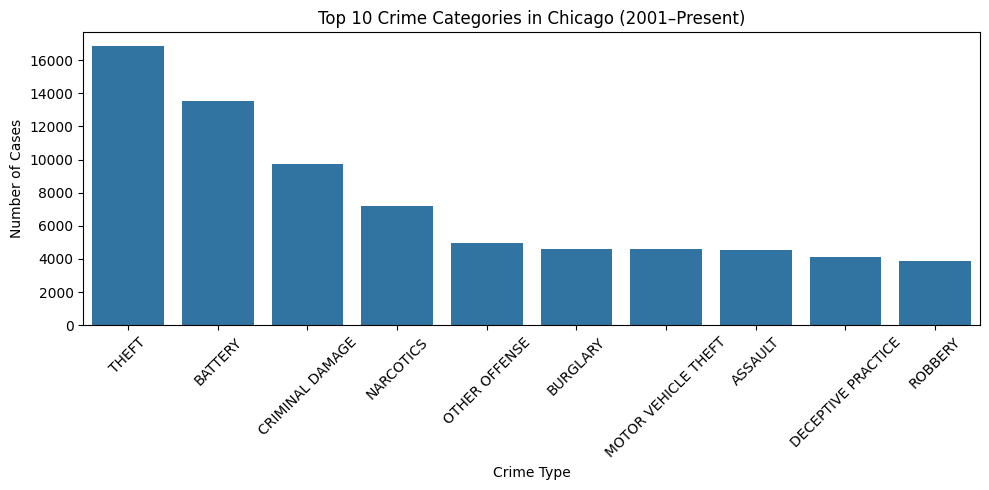

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert SQL results to Pandas for visualization
top_crimes = spark.sql("""
    SELECT `Primary Type`, COUNT(*) AS total
    FROM crimes
    GROUP BY `Primary Type`
    ORDER BY total DESC
    LIMIT 10
""").toPandas()

# Bar Chart of Top Crimes
plt.figure(figsize=(10,5))
sns.barplot(x='Primary Type', y='total', data=top_crimes)
plt.xticks(rotation=45)
plt.title("Top 10 Crime Categories in Chicago (2001–Present)")
plt.xlabel("Crime Type")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()


# WEEK 4

## Data Exploration with PySpark (Alternative to BigQuery)


In [94]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, max, min, sum, count, rank, lag, lead, row_number
from pyspark.sql.window import Window

In [95]:
# spark = SparkSession.builder.appName("ChicagoCrime_SQL_Analysis").getOrCreate()

# # Load dataset
# df = spark.read.csv("/content/drive/MyDrive/archive (1)/Crimes_2001_to_Present_preprocessed.csv", header=True, inferSchema=True)
df = df.dropna(subset=["Primary Type", "District", "Year"])  # basic cleaning

# Simulate another dataset (e.g., district info)
district_data = [
    (1, "Central"), (2, "Wentworth"), (3, "Grand Crossing"), (4, "South Chicago")
]
district_df = spark.createDataFrame(district_data, ["District", "District_Name"])

In [97]:
# ---- 🔹 JOIN OPERATIONS ----
inner_join = df.join(district_df, on="District", how="inner")
left_join  = df.join(district_df, on="District", how="left")
right_join = df.join(district_df, on="District", how="right")
full_join  = df.join(district_df, on="District", how="outer")

print("✅ Inner Join Sample:")
inner_join.select("District", "District_Name", "Primary Type", "Year").show(5)

✅ Inner Join Sample:
+--------+-------------+--------------------+----+
|District|District_Name|        Primary Type|Year|
+--------+-------------+--------------------+----+
|       1|      Central|               THEFT|2011|
|       1|      Central|PUBLIC PEACE VIOL...|2011|
|       1|      Central|               THEFT|2011|
|       1|      Central|     CRIMINAL DAMAGE|2011|
|       1|      Central|               THEFT|2011|
+--------+-------------+--------------------+----+
only showing top 5 rows



In [98]:
# ---- 🔹 AGGREGATION FUNCTIONS ----
agg_df = df.groupBy("Year").agg(
    count("*").alias("Total_Crimes"),
    max("District").alias("Max_District"),
    min("District").alias("Min_District")
)
agg_df.orderBy("Year").show(5)

+----+------------+------------+------------+
|Year|Total_Crimes|Max_District|Min_District|
+----+------------+------------+------------+
|2001|        4144|          25|           1|
|2002|        4734|          25|           1|
|2003|        4608|          25|           1|
|2004|        4527|          25|           1|
|2005|        4373|          25|           1|
+----+------------+------------+------------+
only showing top 5 rows



In [99]:
# ---- 🔹 WINDOW FUNCTIONS ----
windowSpec = Window.partitionBy("Year").orderBy(col("District").desc())

ranked_df = df.select("Year", "District", "Primary Type") \
    .withColumn("Rank", rank().over(windowSpec)) \
    .withColumn("Row_Num", row_number().over(windowSpec)) \
    .withColumn("Prev_District", lag("District", 1).over(windowSpec)) \
    .withColumn("Next_District", lead("District", 1).over(windowSpec))

ranked_df.show(10)

+----+--------+------------------+----+-------+-------------+-------------+
|Year|District|      Primary Type|Rank|Row_Num|Prev_District|Next_District|
+----+--------+------------------+----+-------+-------------+-------------+
|2001|      25|          BURGLARY|   1|      1|         NULL|           25|
|2001|      25|           ASSAULT|   1|      2|           25|           25|
|2001|      25|   CRIMINAL DAMAGE|   1|      3|           25|           25|
|2001|      25|   CRIMINAL DAMAGE|   1|      4|           25|           25|
|2001|      25|           ASSAULT|   1|      5|           25|           25|
|2001|      25|DECEPTIVE PRACTICE|   1|      6|           25|           25|
|2001|      25|             THEFT|   1|      7|           25|           25|
|2001|      25|             THEFT|   1|      8|           25|           25|
|2001|      25|     OTHER OFFENSE|   1|      9|           25|           25|
|2001|      25|   CRIMINAL DAMAGE|   1|     10|           25|           25|
+----+------

## Step 2: Visualization and Insights

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Convert aggregated data to Pandas for visualization
agg_pd = agg_df.toPandas()


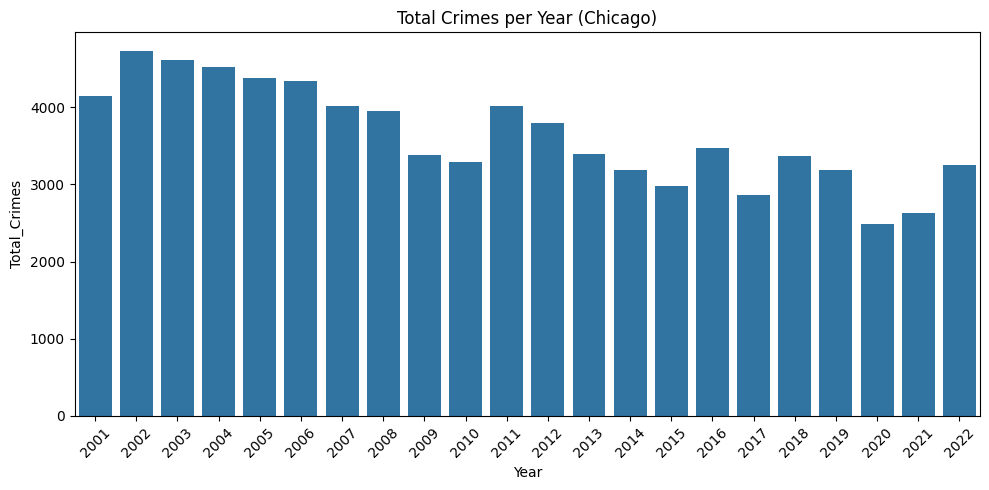

In [101]:


# 🔹 Bar Chart – Total Crimes per Year
plt.figure(figsize=(10,5))
sns.barplot(x='Year', y='Total_Crimes', data=agg_pd)
plt.title("Total Crimes per Year (Chicago)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


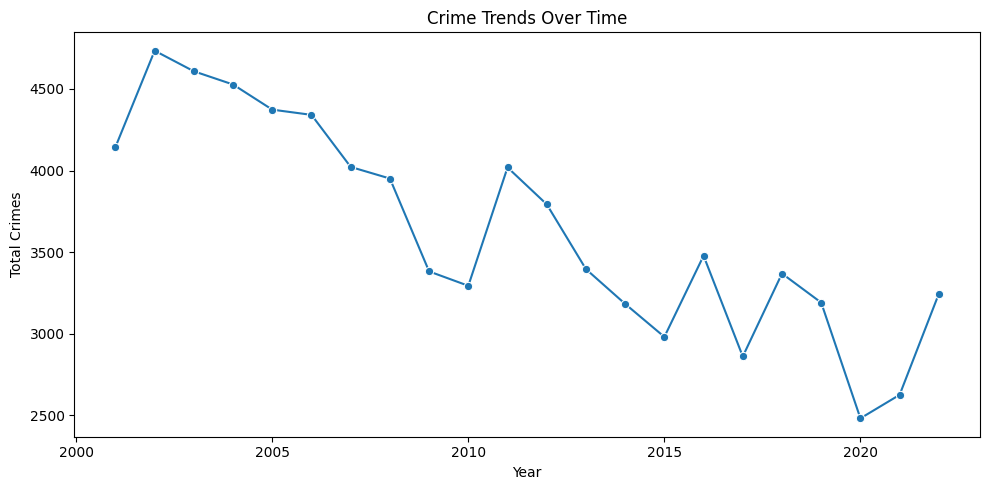

In [102]:
# 🔹 Line Plot – Trend of Crimes over Time
plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='Total_Crimes', data=agg_pd, marker="o")
plt.title("Crime Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.tight_layout()
plt.show()


Crime Type vs Year Heatmap (for temporal analysis)

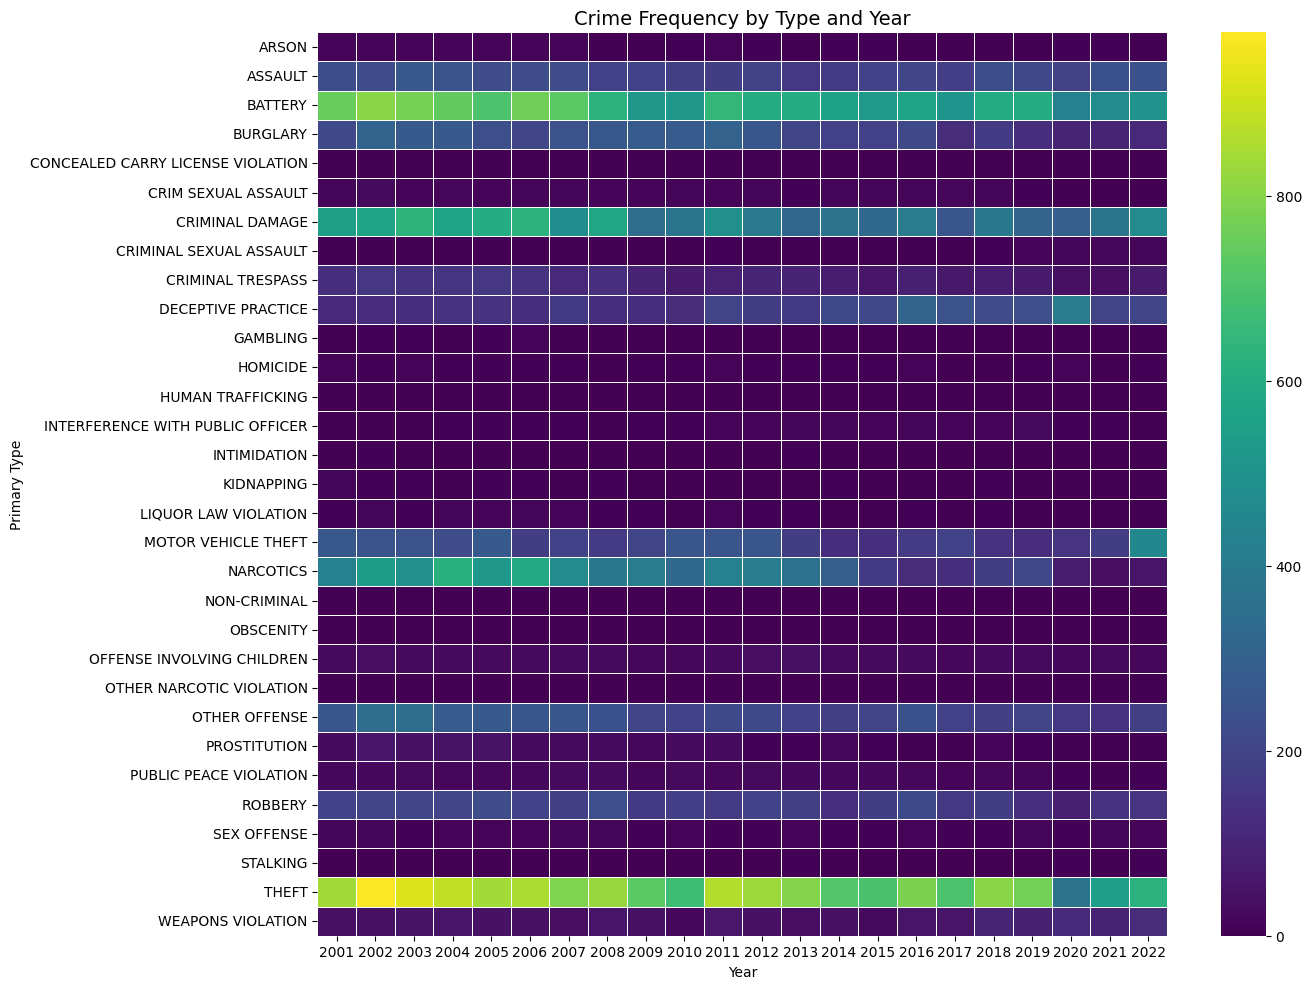

In [109]:
crime_type_heat = (
    df.groupBy("Year", "Primary Type")
      .count()
      .toPandas()
      .groupby(["Primary Type", "Year"])["count"].sum().unstack().fillna(0)

)

plt.figure(figsize=(14,10))
sns.heatmap(crime_type_heat, cmap="viridis", linewidths=0.4)
plt.title("Crime Frequency by Type and Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Primary Type")
plt.tight_layout()
plt.show()

 District vs Type (for spatial analysis)

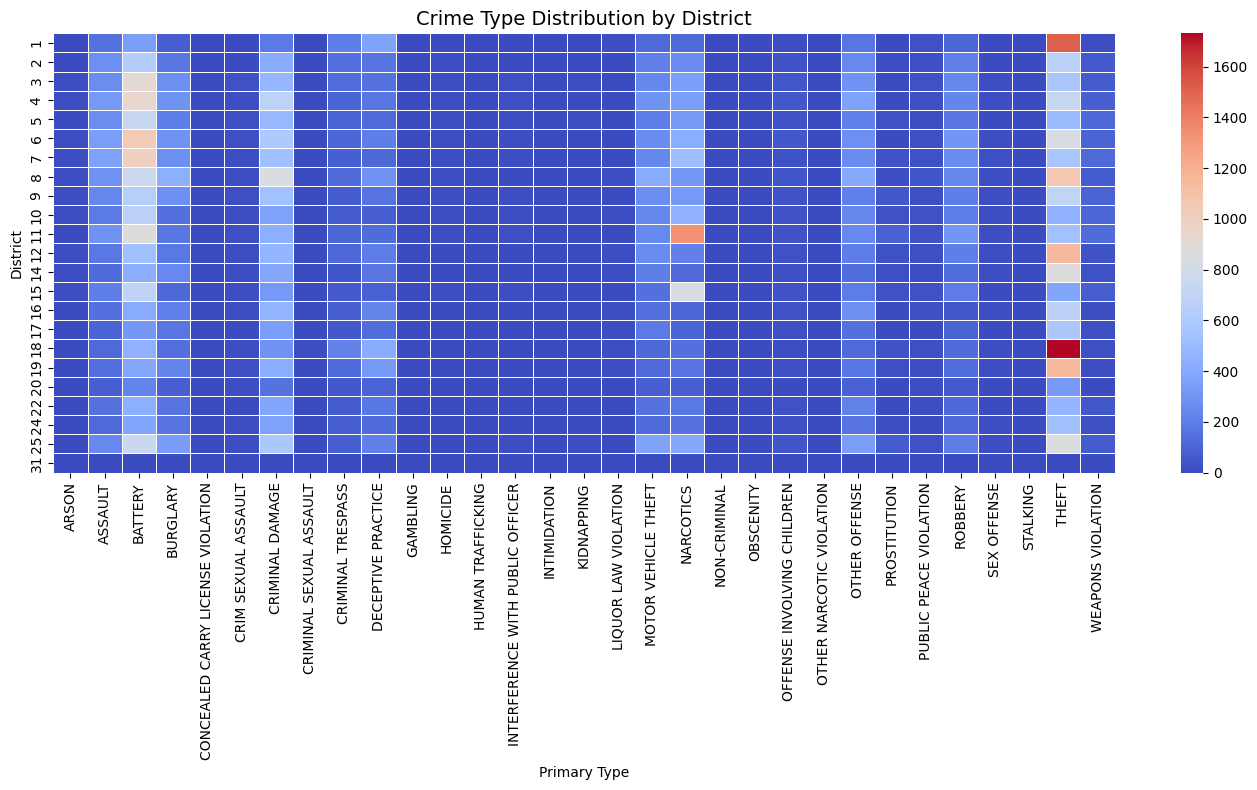

In [111]:
district_heat = (
    df.groupBy("District", "Primary Type")
      .count()
      .toPandas()
      .groupby(["District", "Primary Type"])["count"].sum().unstack().fillna(0)
)

plt.figure(figsize=(14,8))
sns.heatmap(district_heat, cmap="coolwarm", linewidths=0.4)
plt.title("Crime Type Distribution by District", fontsize=14)
plt.xlabel("Primary Type")
plt.ylabel("District")
plt.tight_layout()
plt.show()